In [2]:
from bubble_data_collector import *

In [1]:
import os
os.chdir('/content/ece143-bubble-analysis')

## Dataset Creation
The dataset is created through the WRDS database and requires a login to access. If the data directory is not created, this following block of code needs to be run, as it will create the .csv files needed for the rest of the notebook. Otherwise, this block can be ignored and skipped.

In [3]:
generate_all_bubble_csvs(
        config_path="bubble_config.json",
        output_dir="data",
        start_date="1995-01-01",
  )

Enter your WRDS username [root]:a4kapoor
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done

[INFO] Building panel for bubble: ai
ai initial matches:
    gvkey                          conm    tic
0  060703  2X DAILY SOFTWARE PLATFM ETF   SOFL
1  138490  3-DIMENSIONAL PHARMACEUTICAL   DDDP
2  317168                 4D PHARMA PLC   LBPS
3  042890  60 DEGREES PHARMACEUTICA INC   SXTP
4  033048        9 METERS BIOPHARMA INC  NMTRQ
['NVDA', 'AMD', 'AVGO', 'INTC', 'ARM', 'TSM', 'ASML', 'MU', 'SMCI', 'DELL', 'HPE', 'MSFT', 'GOOGL', 'AMZN', 'META', 'ORCL', 'IBM', 'PLTR', 'SNOW', 'DDOG', 'NOW', 'CRWD', 'PATH', 'AI', 'ZS', 'OKTA', 'TEAM', 'MDB', 'TXN', 'ADBE', 'CRM', 'SAP']
NVIDIA CORP|ADVANCED MICRO DEVICES INC|BROADCOM INC|INTEL CORP|ARM HOLDINGS PLC|TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD|ASML HOLDING NV|MICRON TECHNOLOG

/content/ece143-bubble-analysis/bubble_data_collector.py:181: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (firm_list["conm"].str.upper().str.contains(name_pattern))


[OK] Saved dotcom panel to data/dotcom_merged.csv


## Loading in the Merged Dataset
Once the .csv files have been created and stored in the data directory, the following blocks can be run to load the dataset into a merged dataframe that contains the required information for each bubble.

In [4]:
config_path = "bubble_config.json"
config = load_bubble_config(config_path) #Creates a directory for the data config

In [5]:
for bubble_type, cfg in config.items():
    merged = pd.read_csv(cfg['data_path'])

## Data Visualizations

Loading may take a few seconds. Please wait for the drop down mneu to show up and then go ahead use it to see different plots

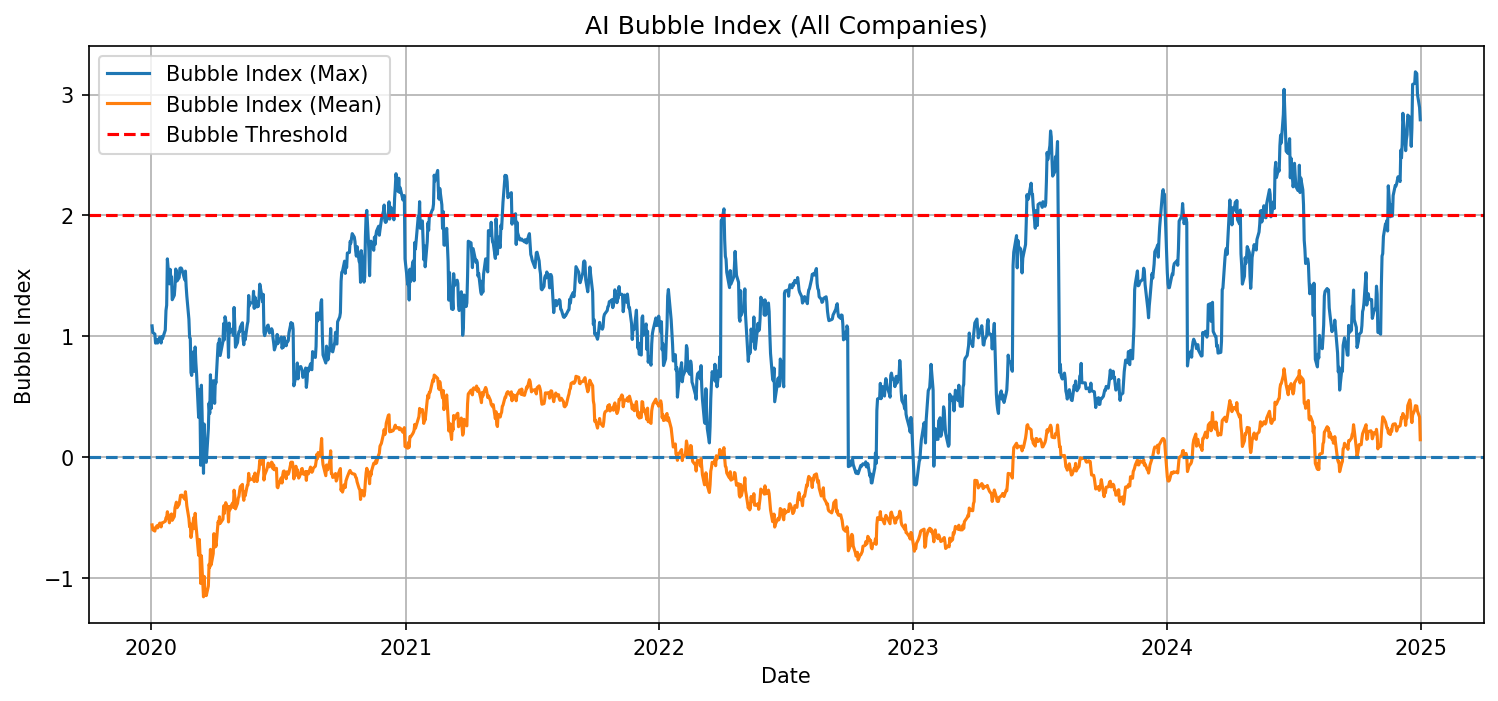

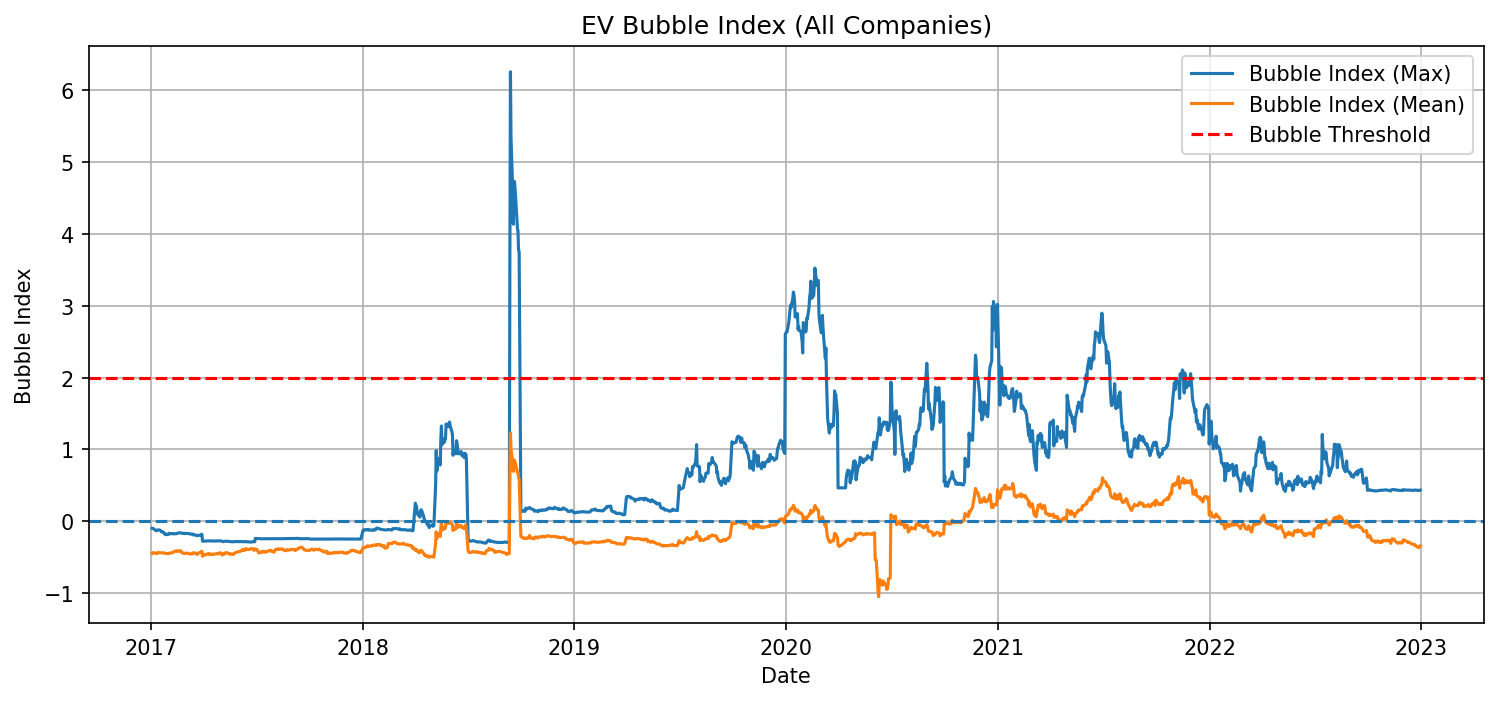

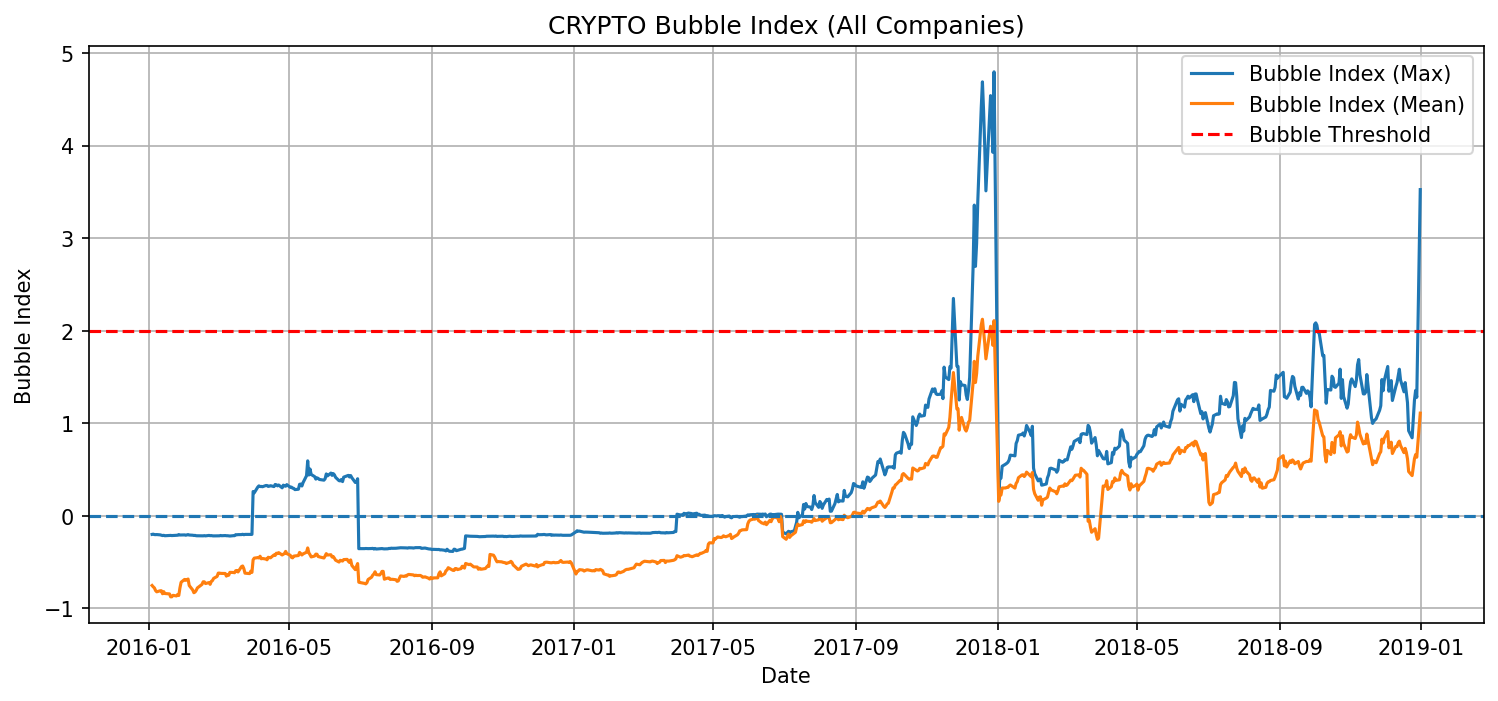

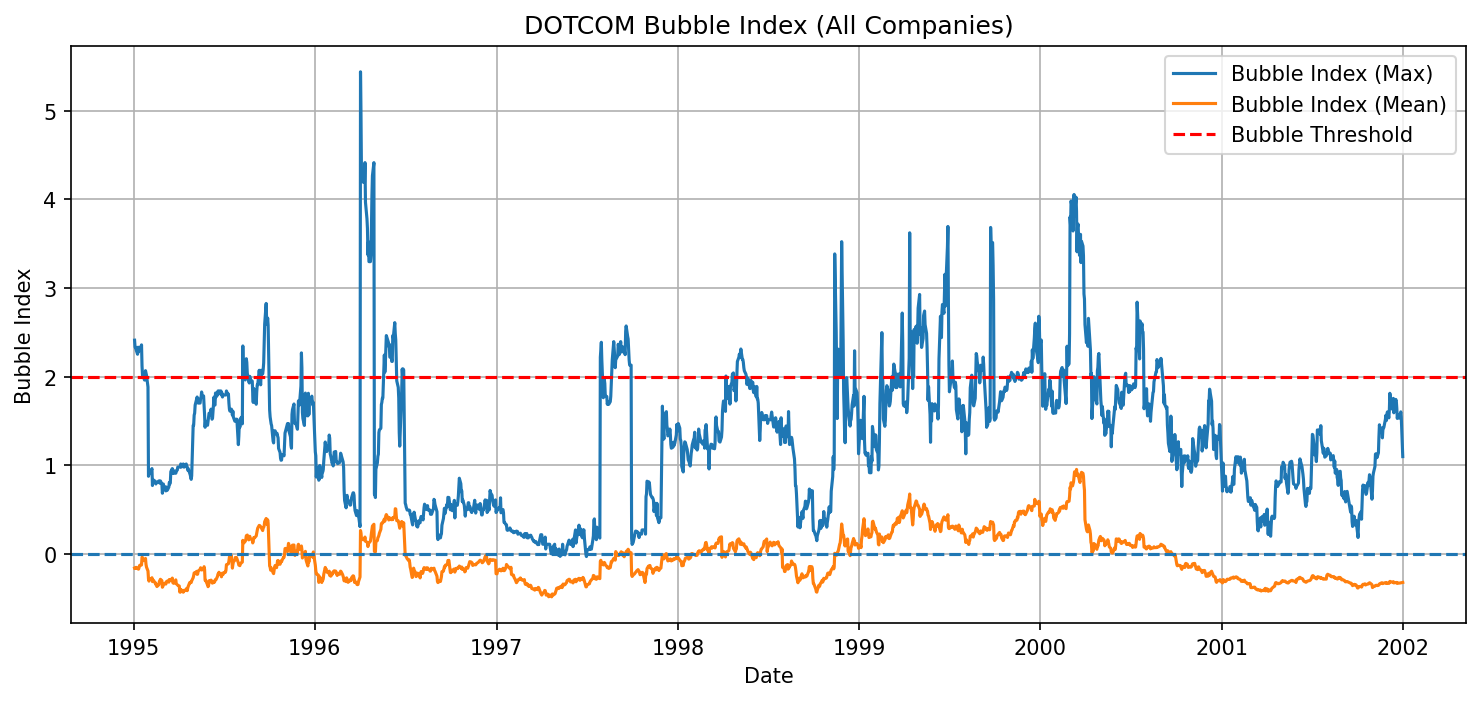

interactive(children=(Dropdown(description='Bubble:', options=('ai', 'ev', 'crypto', 'dotcom'), value='ai'), D…

<Figure size 640x480 with 0 Axes>

In [6]:
%run bubble_plotting_interactive.py

In [7]:
!pip install -U kaleido

In [9]:
%run bubble_heatmap.py

## Random Forest

In [ ]:
from run import *

In [ ]:
main()


===========:crypto Bubble window: ===========
Start → 2016Q1
Peak → 2021Q2
End  → 2022Q4
===========:dotcom Bubble window: ===========
Start → 1995Q1
Peak → 2000Q1
End  → 2001Q2
===========:ev Bubble window: ===========
Start → 2017Q1
Peak → 2020Q3
End  → 2023Q1
===========:ai Bubble window: ===========
Start → 2020Q1
Peak → 2020Q1
End  → 2024Q4
========= Feature Importances: =========
prc: 0.1062
mktcap: 0.0752
ps: 0.0589
pb: 0.1083
pe: 0.1035
ev: 0.0889
ev_sales: 0.0627
ps_z: 0.0531
pb_z: 0.2948
ev_sales_z: 0.0484
================ Predictions: =====================
   permno  survival_prob_predicted         prc        mktcap             ps  \
0   13447                 0.179857  564.066979  1.132120e+08   65297.275516   
1   19654                 0.235359  200.387361  5.383596e+07  131463.530040   
2   19788                 0.211460   20.066393  3.866564e+07   78332.701297   
3   20193                 0.108239   36.601283  3.808618e+06   63643.524417   
4   20972                 0.119

In [28]:
import nbformat

nb_path = "data_vis_update_fin4.ipynb"

# Load notebook
with open(nb_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)
changed = False

# ---- 1. Remove global widget metadata ----
if "widgets" in nb.metadata:
    print("Removing notebook-level metadata.widgets…")
    nb.metadata.pop("widgets")
    changed = True

# ---- 2. Remove widget metadata inside each cell ----
for cell in nb.cells:
    # Remove cell metadata
    if "widgets" in cell.get("metadata", {}):
        print("Removing cell metadata.widgets…")
        cell.metadata.pop("widgets")
        changed = True

    # Remove widget states embedded in outputs
    if "outputs" in cell:
        for out in cell.outputs:
            if hasattr(out, "data") and "application/vnd.jupyter.widget-view+json" in out.data:
                print("Removing widget output data…")
                out.data.pop("application/vnd.jupyter.widget-view+json", None)
                changed = True
            if hasattr(out, "data") and "application/vnd.jupyter.widget-state+json" in out.data:
                print("Removing widget state blob…")
                out.data.pop("application/vnd.jupyter.widget-state+json", None)
                changed = True

# ---- 3. Save cleaned notebook ----
if changed:
    with open(nb_path, "w", encoding="utf-8") as f:
        nbformat.write(nb, f)
    print("\n✔ Notebook cleaned successfully. GitHub will now render it.")
else:
    print("\nNo widget metadata found. Notebook unchanged.")

Removing notebook-level metadata.widgets…
Removing widget output data…

✔ Notebook cleaned successfully. GitHub will now render it.
